In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

drive_path = "/content/drive/MyDrive/PROJECT_FSD50K"
local_path = "/content/fsd50k_local"

# Only extract the audio archives if they haven't been extracted already
dev_audio_dir = os.path.join(local_path, "FSD50K.dev_audio")

if os.path.exists(dev_audio_dir) and len(os.listdir(dev_audio_dir)) > 100:
    print(f"Dataset already extracted at {local_path}")
else:
    print("Extracting dataset archives")
    !unzip -q {drive_path}/FSD50K.metadata.zip -d {local_path}
    !unzip -q {drive_path}/FSD50K.ground_truth.zip -d {local_path}
    !7z x {drive_path}/FSD50K.eval_audio.zip -o{local_path} -y > /dev/null
    !7z x {drive_path}/FSD50K.dev_audio.zip -o{local_path} -y > /dev/null
    print("Extraction complete.")

Mounted at /content/drive
Dataset already extracted at /content/fsd50k_local


# **CNN Baseline: ResNet-18 on Mel-Spectrograms**

## **Purpose**

This notebook trains a ResNet-18 convolutional neural network on Mel-spectrograms of the FSD50K dataset. It serves as the convolutional baseline against which the AST model (notebook `05_ast`) will be compared, both in clean conditions and under acoustic noise (notebook `06_robutness`).

The key design decisions are:

- **Vocabulary**: the 100-class vocabulary defined by the redundancy analysis in `03_label_correlation_analysis`.
- **Architecture**: ResNet-18 adapted for single-channel Mel-spectrograms, trained from scratch.
- **Regularization**: SpecAugment applied during training as part of the standard audio classification pipeline (Fonseca et al. 2020, Kong et al. 2020).
- **Training protocol**: AdamW optimizer, `ReduceLROnPlateau` scheduler, and principled early stopping based on validation mAP.

The final checkpoint and predictions are saved to Drive for use in the robustness evaluation.

## **Library Imports and Environment Setup**

This section imports all the libraries required for the Convolutional Neural Network pipeline. Unlike the baseline MLP, the CNN model operates directly on Mel-spectrogram representations treated as single-channel images, so we rely on `torch`, `torchaudio` and `torchvision` for tensor operations, audio processing and the ResNet architecture respectively. We also fix the random seeds in both NumPy and PyTorch to guarantee reproducibility between training runs, which is particularly relevant when comparing with the AST model in later notebooks.

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from torchvision.models import resnet18
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
import json

# Detect whether a CUDA-compatible GPU is available and move all tensors there
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Fix random seeds for reproducibility across runs
torch.manual_seed(42)
np.random.seed(42)

Device: cuda


## **Dataset Paths and Ground Truth Loading**

In this section, we define the paths to the FSD50K metadata, ground truth annotations, and the audio directories for both the development and evaluation splits. Since FSD50K provides an official `split` column inside `dev.csv`, no manual train/validation partition is required. The code constructs the full path to each audio file and parses the multi-label annotations into Python lists, which is the expected format for `MultiLabelBinarizer` in the following steps.

In [ ]:
# Base directory where the FSD50K dataset has been extracted
BASE_DIR   = "/content/fsd50k_local"
# Path to the development ground truth (contains train/val split column)
DEV_CSV    = os.path.join(BASE_DIR, "FSD50K.ground_truth", "dev.csv")
# Path to the evaluation ground truth (official test set)
EVAL_CSV   = os.path.join(BASE_DIR, "FSD50K.ground_truth", "eval.csv")
# Path to the vocabulary file listing all 200 official classes
VOCAB_CSV  = os.path.join(BASE_DIR, "FSD50K.ground_truth", "vocabulary.csv")
# Directory containing the development audio files (train + val)
DEV_AUDIO  = os.path.join(BASE_DIR, "FSD50K.dev_audio")
# Directory containing the evaluation audio files (final test)
EVAL_AUDIO = os.path.join(BASE_DIR, "FSD50K.eval_audio")

# Load the ground truth tables for both splits
dev_df  = pd.read_csv(DEV_CSV)
eval_df = pd.read_csv(EVAL_CSV)

# Build the absolute path to each audio file
dev_df["path"]  = dev_df["fname"].astype(str).apply(lambda x: os.path.join(DEV_AUDIO,  f"{x}.wav"))
eval_df["path"] = eval_df["fname"].astype(str).apply(lambda x: os.path.join(EVAL_AUDIO, f"{x}.wav"))

# Parse the comma-separated multi-label strings into actual Python lists
dev_df["label_list"]  = dev_df["labels"].astype(str).str.split(",")
eval_df["label_list"] = eval_df["labels"].astype(str).str.split(",")

print(f"Total dev samples: {len(dev_df)}  |  Total eval samples: {len(eval_df)}")

Total dev samples: 40966  |  Total eval samples: 10231


## **Class Selection: Loading Vocabulary from Notebook 03**

The label space used throughout this notebook is determined by the redundancy analysis performed in `03_label_correlation_analysis.ipynb`. That notebook identifies three labels whose co-occurrence with another label exceeds 95% in both directions (`Musical_instrument`, `Plucked_string_instrument`, `Thunderstorm`), and defines the final vocabulary as the 100 most frequent labels of the development set after removing those three redundant ones.

We load that configuration here from Drive so that every trained model shares the same label space and the elimination criterion remains auditable. Samples that do not contain at least one label in the final vocabulary are discarded.

In [ ]:
# Load the vocabulary configuration produced in Notebook 03

with open("/content/drive/MyDrive/PROJECT_FSD50K/label_config.json") as f:
    cfg = json.load(f)

DROP_LABELS     = set(cfg["drop_labels"])
VOCAB_SIZE      = cfg["vocabulary_size"]
print(f"Loaded vocabulary config: drop={sorted(DROP_LABELS)}  size={VOCAB_SIZE}")

# Count label frequencies and build the final Top-100 vocabulary
all_labels   = [lab for labs in dev_df["label_list"] for lab in labs]
label_counts = Counter(all_labels)

# Selection rule: drop redundant labels first, then take Top-N by frequency
top_labels = [l for l, _ in label_counts.most_common() if l not in DROP_LABELS][:VOCAB_SIZE]

print(f"Final number of classes: {len(top_labels)}")
print(f"Minimum support in the final vocabulary: "
      f"{min(label_counts[l] for l in top_labels)} samples")

# Filter each sample to keep only labels that belong to the final vocabulary
def filter_labels(lst):
    return [l for l in lst if l in top_labels]

dev_df["label_filt"]  = dev_df["label_list"].apply(filter_labels)
eval_df["label_filt"] = eval_df["label_list"].apply(filter_labels)

# Remove samples that no longer contain any valid label after filtering
dev_df  = dev_df[dev_df["label_filt"].apply(len) > 0].reset_index(drop=True)
eval_df = eval_df[eval_df["label_filt"].apply(len) > 0].reset_index(drop=True)

# Split development data according to the official train/val partition
train_df = dev_df[dev_df["split"] == "train"].reset_index(drop=True)
val_df   = dev_df[dev_df["split"] == "val"].reset_index(drop=True)
test_df  = eval_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

# Fit the MultiLabelBinarizer on the fixed class list to ensure consistent column ordering
mlb = MultiLabelBinarizer(classes=top_labels)
mlb.fit([top_labels])
NUM_CLASSES = len(top_labels)

Loaded vocabulary config: drop=['Musical_instrument', 'Plucked_string_instrument', 'Thunderstorm']  size=100
Final number of classes: 100
Minimum support in the final vocabulary: 220 samples

Train: 35685  |  Val: 4006  |  Test: 9878


## **Audio Preprocessing Constants and Mel-Spectrogram Transform**

This section defines the fixed audio parameters used throughout the CNN pipeline. All clips are resampled to 16 kHz (the same sampling rate used in the baseline and the one expected by AST, enabling fair comparison later). Each clip is truncated or zero-padded to a fixed duration of 10 seconds, which corresponds to the mean duration observed in the EDA. The Mel-spectrogram is computed using 128 Mel bins, an FFT size of 1024 and a hop of 512, producing a 2D tensor of shape `(128, 313)` that will be treated as a single-channel image by the ResNet. Amplitude values are converted to the decibel scale, which compresses dynamic range and makes the input more amenable to convolutional feature extraction.

In [ ]:
# Audio preprocessing parameters
SR        = 16000               # target sampling rate in Hz
DURATION  = 10                  # fixed clip duration in seconds
N_SAMPLES = SR * DURATION       # total samples per clip after padding/truncation
N_MELS    = 128                 # number of Mel frequency bins
N_FFT     = 1024                # FFT window size
HOP       = 512                 # hop length between consecutive frames

# Transform that maps raw waveform to Mel-spectrogram (power scale)
mel_transform = T.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS
)
# Transform that converts amplitude to decibels with a dynamic range of 80 dB
db_transform = T.AmplitudeToDB(top_db=80)

## **Custom PyTorch Dataset with Mel-Spectrograms and Optional Noise Injection**

This section implements the `FSD50KMelDataset`, a custom PyTorch `Dataset` responsible for loading audio, computing Mel-spectrograms and returning multi-label targets. Three design choices are worth highlighting:

- **SpecAugment** is applied only during training when `augment=True`, masking random frequency and time regions of the spectrogram. This regularizes the model and forces it to learn more robust representations.
- **Per-clip normalization** (mean 0, std 1) is applied after the dB conversion, which reduces the effect of absolute loudness differences between clips.
- **Gaussian noise injection** is supported through the `noise_snr_db` argument. This is used only during the robustness experiments (Notebook 06). It is disabled here but defined in the base class to keep a consistent dataset interface across notebooks.

In [ ]:
class FSD50KMelDataset(Dataset):
    def __init__(self, df, mlb, augment=False, noise_snr_db=None):
        # DataFrame with one row per audio clip (includes path and label_filt)
        self.df = df.reset_index(drop=True)
        # Pre-fitted MultiLabelBinarizer used to build the target vectors
        self.mlb = mlb
        # Whether to apply SpecAugment during training
        self.augment = augment
        # SNR in dB for optional Gaussian noise injection (None = clean)
        self.noise_snr = noise_snr_db
        # SpecAugment: frequency masking up to 24 bins, time masking up to 40 frames
        self.spec_aug = nn.Sequential(
            T.FrequencyMasking(freq_mask_param=24),
            T.TimeMasking(time_mask_param=40),
        )

    def __len__(self):
        return len(self.df)

    def _load_wave(self, path):
        # Load audio file as a torch tensor
        wav, sr = torchaudio.load(path)
        # Convert to mono by averaging channels if stereo
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        # Resample to the target sampling rate if necessary
        if sr != SR:
            wav = torchaudio.functional.resample(wav, sr, SR)
        wav = wav.squeeze(0)
        # Truncate or zero-pad to a fixed length
        if wav.shape[0] > N_SAMPLES:
            wav = wav[:N_SAMPLES]
        else:
            wav = F.pad(wav, (0, N_SAMPLES - wav.shape[0]))
        return wav

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Load and normalize waveform; fall back to zeros if the file is corrupted
        try:
            wav = self._load_wave(row["path"])
        except Exception:
            wav = torch.zeros(N_SAMPLES)

        # Optional Gaussian noise injection at a specific SNR (robustness experiments)
        if self.noise_snr is not None:
            sig_p   = (wav**2).mean().item() + 1e-10
            noise_p = sig_p / (10 ** (self.noise_snr / 10))
            wav     = wav + torch.randn_like(wav) * (noise_p ** 0.5)

        # Compute the Mel-spectrogram and convert to dB scale
        mel = db_transform(mel_transform(wav))
        # Per-clip standardization to stabilize training
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        # SpecAugment during training only
        if self.augment:
            mel = self.spec_aug(mel.unsqueeze(0)).squeeze(0)
        # Add channel dimension so the tensor has shape (1, n_mels, time)
        mel = mel.unsqueeze(0)
        # Build the binary multi-label target vector
        y = self.mlb.transform([row["label_filt"]])[0].astype(np.float32)
        return mel, torch.from_numpy(y)

## **DataLoader Construction**

This section builds the PyTorch `DataLoader` objects for the train, validation and test splits. The training loader enables shuffling and SpecAugment, while validation and test loaders keep the data deterministic so that evaluation metrics are comparable across runs. Batch size is set to 32. Two worker processes and `pin_memory=True` are enabled to speed up CPU-to-GPU transfers.

In [ ]:
BATCH = 32

# Training loader: shuffled, with SpecAugment enabled
train_ds     = FSD50KMelDataset(train_df, mlb, augment=True)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)

# Validation loader: no shuffle, no augmentation
val_ds     = FSD50KMelDataset(val_df, mlb, augment=False)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)

# Test loader: evaluation set of FSD50K, clean and deterministic
test_ds     = FSD50KMelDataset(test_df, mlb, augment=False)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"Batches per epoch:  train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")

Batches per epoch:  train=1116  val=126  test=309


## **Model Architecture: ResNet-18 Adapted for Single-Channel Spectrograms**

This section defines the CNN architecture. We use a ResNet-18 as the backbone because it strikes a good balance between representational capacity and training cost: it has around 11 million parameters, making it significantly more efficient than the AST model used for comparison.
To adapt this architecture (originally designed for color images) to our audio task, we performed two key modifications:

**Input Layer Adaptation (1-Channel):** Standard ResNet-18 expects RGB inputs (3 channels). Since our Mel-spectrograms are single-channel (grayscale representation of frequency over time), we replaced the first convolutional layer (conv1) with a new nn.Conv2d that accepts 1 input channel. This ensures the model is compatible with our data shape without adding redundant information.

**Output Layer & Multi-label Support:** The final fully-connected layer was replaced by a new linear layer with ``NUM_CLASSES`` outputs. Unlike standard classification, we do not use a Softmax; instead, we produce one logit per class.

**Loss Function:** We use ``BCEWithLogitsLoss``, which implicitly applies a Sigmoid activation. This is the correct choice for multi-label classification, as it allows the model to predict multiple independent labels for a single audio clip (e.g., "Bird" and "Rain" simultaneously).


In [ ]:
def build_cnn(num_classes):
    # Instantiate ResNet-18 without pre-trained weights
    model = resnet18(weights=None)
    # Replace the first conv layer to accept single-channel spectrograms
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    # Replace the final FC layer with one that outputs NUM_CLASSES logits
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# Build and move the model to the available device
model = build_cnn(NUM_CLASSES).to(device)

# Count the trainable parameters for reporting
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params/1e6:.2f} M")

Trainable parameters: 11.22 M


## **Training and Evaluation Loop Utilities**

This section defines two helper functions used throughout training. `run_epoch` executes a full pass over a DataLoader. When `train=True` it also performs the backward pass and optimizer step. The function returns the average loss along with the full arrays of ground-truth labels and predicted probabilities, which are then used to compute metrics. The `metrics` function computes micro-F1, macro-F1 and macro-mAP, which are the three standard metrics in FSD50K-based literature.

In [ ]:
def run_epoch(loader, train=True):
    # Switch between train and eval modes (affects BatchNorm and Dropout)
    model.train(train)
    losses, all_y, all_p = [], [], []
    pbar = tqdm(loader, leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                optim_.zero_grad()
                loss.backward()
                optim_.step()
        losses.append(loss.item())
        all_y.append(y.detach().cpu().numpy())
        all_p.append(torch.sigmoid(logits).detach().cpu().numpy())
        pbar.set_postfix(loss=np.mean(losses))
    # Concatenate all batches into full arrays
    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_p)
    return np.mean(losses), y_true, y_prob

def metrics(y_true, y_prob, th=0.3):
    # Convert probabilities to binary predictions using the threshold
    y_pred = (y_prob >= th).astype(int)
    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mAP":      average_precision_score(y_true, y_prob, average="macro"),
    }

## **Training the CNN Model with Principled Early Stopping**

The training loop uses early stopping based on validation mAP, letting the data determine when to halt rather than fixing a number of epochs a priori. Key choices:

- **Scheduler: `ReduceLROnPlateau`** (standard in the FSD50K literature - Fonseca et al. 2020, PANNs Kong et al. 2020). Halves the LR when val_mAP stalls, which is compatible with early stopping and reactive to actual training dynamics.
- **`MAX_EPOCHS = 50`**: Gives ample room for convergence on a 100-class, 37k-sample problem.
- **`PATIENCE = 5`**: tolerates the ~0.01 single-epoch oscillations observed in preliminary runs before concluding that the model has plateaued.
- **`MIN_DELTA = 0.001`**: one order of magnitude below the observed noise, so true progress is captured without random fluctuations resetting the counter.
- **Scheduler patience (2) < early-stopping patience (5)** by design: the scheduler reduces the LR first, giving the model a second chance before training halts.

The best checkpoint on validation mAP is retained and restored before test evaluation.

In [ ]:

# Training loop with early stopping
MAX_EPOCHS = 50
PATIENCE   = 5
MIN_DELTA  = 0.001

# Optimizer: AdamW, standard for multi-label CNNs
optim_ = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Scheduler: ReduceLROnPlateau monitoring val_mAP
# Inner patience=2 < outer patience=5 so the scheduler acts before early stop
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim_, mode='max', factor=0.5, patience=2, min_lr=1e-6
)
criterion = nn.BCEWithLogitsLoss()

best_map         = 0.0
best_state       = None
patience_counter = 0
stopped_at       = None

history = {"train_loss": [], "val_loss": [], "val_map": [],
           "val_microF1": [], "lr": []}

for ep in range(1, MAX_EPOCHS + 1):
    tr_loss, _, _          = run_epoch(train_loader, train=True)
    val_loss, y_val, p_val = run_epoch(val_loader,   train=False)
    m = metrics(y_val, p_val, th=0.3)

    # Scheduler reacts to val_mAP, not to a fixed calendar
    sched.step(m["mAP"])
    current_lr = optim_.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_map"].append(m["mAP"])
    history["val_microF1"].append(m["micro_f1"])
    history["lr"].append(current_lr)

    # Update best checkpoint only on meaningful improvement
    improved = m["mAP"] > (best_map + MIN_DELTA)
    if improved:
        best_map   = m["mAP"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        tag = "NEW BEST"
    else:
        patience_counter += 1
        tag = f"no improvement ({patience_counter}/{PATIENCE})"

    print(f"[Ep {ep:02d}] train={tr_loss:.4f}  val={val_loss:.4f}  "
          f"microF1={m['micro_f1']:.4f}  macroF1={m['macro_f1']:.4f}  "
          f"mAP={m['mAP']:.4f}  lr={current_lr:.1e}  [{tag}]")

    if patience_counter >= PATIENCE:
        stopped_at = ep
        print(f"\nEarly stopping triggered at epoch {ep}: "
              f"no val_mAP improvement >= {MIN_DELTA} in {PATIENCE} epochs.")
        break

model.load_state_dict(best_state)
total_epochs = stopped_at if stopped_at else MAX_EPOCHS
print(f"\nTraining finished. Total epochs: {total_epochs}. Best val mAP: {best_map:.4f}")

[Ep 01] train=0.0680  val=0.0773  microF1=0.3790  macroF1=0.1718  mAP=0.2667  lr=1.0e-03  [NEW BEST]


[Ep 02] train=0.0517  val=0.0825  microF1=0.3940  macroF1=0.2288  mAP=0.2912  lr=1.0e-03  [NEW BEST]


[Ep 03] train=0.0453  val=0.1031  microF1=0.3310  macroF1=0.2022  mAP=0.2928  lr=1.0e-03  [NEW BEST]


[Ep 04] train=0.0403  val=0.0819  microF1=0.4407  macroF1=0.3158  mAP=0.3704  lr=1.0e-03  [NEW BEST]


[Ep 05] train=0.0363  val=0.0792  microF1=0.4533  macroF1=0.3284  mAP=0.3822  lr=1.0e-03  [NEW BEST]


...

[Ep 13] train=0.0166  val=0.0777  microF1=0.5530  macroF1=0.4493  mAP=0.4891  lr=1.0e-03  [no improvement (1/5)]


[Ep 14] train=0.0146  val=0.0848  microF1=0.5455  macroF1=0.4416  mAP=0.4816  lr=1.0e-03  [no improvement (2/5)]


[Ep 15] train=0.0130  val=0.0777  microF1=0.5718  macroF1=0.4664  mAP=0.5019  lr=5.0e-04  [no improvement (3/5)]


[Ep 16] train=0.0086  val=0.0822  microF1=0.5828  macroF1=0.4827  mAP=0.5164  lr=5.0e-04  [no improvement (4/5)]


[Ep 17] train=0.0073  val=0.0933  microF1=0.5748  macroF1=0.4676  mAP=0.5086  lr=5.0e-04  [no improvement (5/5)]

Early stopping triggered at epoch 17: no val_mAP improvement >= 0.001 in 5 epochs.

Training finished. Total epochs: 17. Best val mAP: 0.5181


## **Training Curves Visualization**

Three diagnostics across the full training trajectory: loss curves (to spot overfitting), validation metrics (the signal used by early stopping), and the learning rate schedule (drops indicate when `ReduceLROnPlateau` triggered on a plateau).

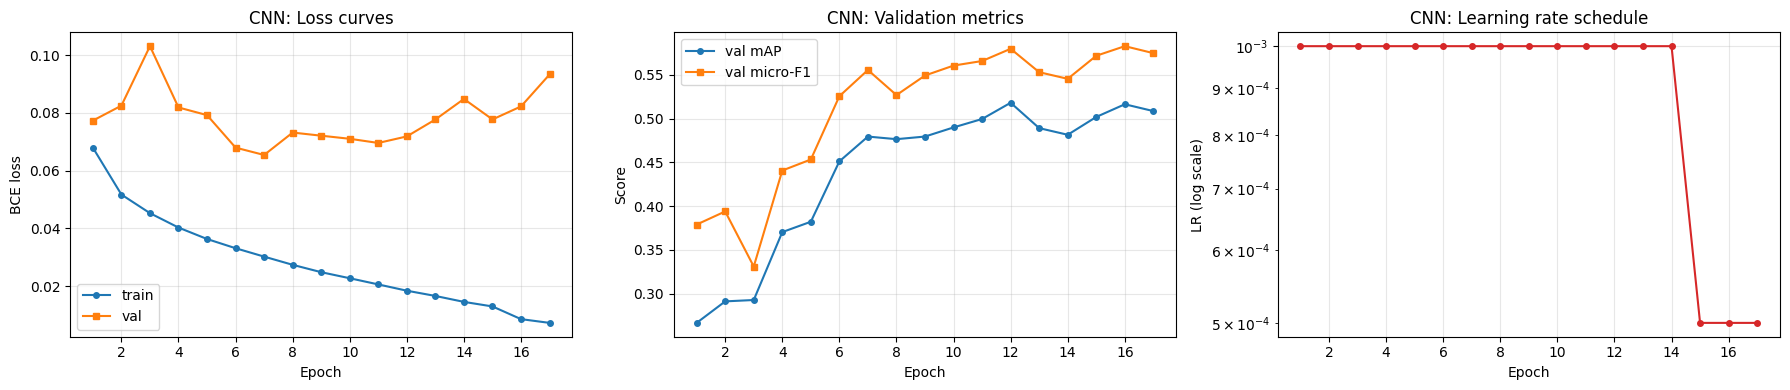

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
epochs_axis = range(1, len(history["train_loss"]) + 1)

# Loss curves
axes[0].plot(epochs_axis, history["train_loss"], label="train", marker="o", markersize=4)
axes[0].plot(epochs_axis, history["val_loss"],   label="val",   marker="s", markersize=4)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("CNN: Loss curves"); axes[0].legend(); axes[0].grid(alpha=.3)

# Validation metrics
axes[1].plot(epochs_axis, history["val_map"],     label="val mAP",      marker="o", markersize=4)
axes[1].plot(epochs_axis, history["val_microF1"], label="val micro-F1", marker="s", markersize=4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("CNN: Validation metrics"); axes[1].legend(); axes[1].grid(alpha=.3)

# Learning rate (log scale to show halvings clearly)
axes[2].plot(epochs_axis, history["lr"], marker="o", markersize=4, color="tab:red")
axes[2].set_yscale("log")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR (log scale)")
axes[2].set_title("CNN: Learning rate schedule"); axes[2].grid(alpha=.3)

plt.tight_layout(); plt.show()

## **Decision Threshold Selection**

In multi-label classification, the model outputs an independent probability for each class and a threshold must be chosen to convert these probabilities into binary decisions. Lower thresholds produce more positive predictions (higher recall, lower precision) and vice versa. This section sweeps a range of thresholds between 0.1 and 0.55 on the validation set and selects the value that maximizes micro-F1. The selected threshold is then used for the final test evaluation.

In [ ]:
# Regenerate validation predictions with the best checkpoint
_, y_val, p_val = run_epoch(val_loader, train=False)

best_th, best_f1 = 0.3, 0.0
# Sweep thresholds in steps of 0.05
for th in np.arange(0.10, 0.60, 0.05):
    f1 = f1_score(y_val, (p_val >= th).astype(int), average="micro", zero_division=0)
    if f1 > best_f1:
        best_f1, best_th = f1, th

print(f"Best threshold on validation (micro-F1): th={best_th:.2f}  F1={best_f1:.4f}")

Best threshold on validation (micro-F1): th=0.30  F1=0.5798


## **Final Evaluation on the Test Set**

We compute metrics on the FSD50K evaluation set using the best checkpoint and the tuned threshold. These numbers represent the definitive, unbiased estimate of the model's generalization performance. Weights and predictions are saved to Drive for use in downstream notebooks (`05_ast` and `06_robustness`).

In [ ]:
# Final test evaluation with the best checkpoint and the tuned threshold
_, y_test, p_test = run_epoch(test_loader, train=False)
test_m = metrics(y_test, p_test, th=best_th)

print("=== CNN final results on FSD50K evaluation set ===")
for k, v in test_m.items():
    print(f"{k:>10s}: {v:.4f}")

# Persist weights and predictions to Drive for downstream notebooks
torch.save(model.state_dict(),
           "/content/drive/MyDrive/PROJECT_FSD50K/cnn_resnet18.pt")
np.savez("/content/drive/MyDrive/PROJECT_FSD50K/cnn_preds.npz",
         y_test=y_test, p_test=p_test,
         classes=np.array(top_labels), best_th=best_th)

## **Per-Class Performance Analysis**

This section breaks down the test performance by class, computing average precision and F1 score independently for each of the 100 classes in the final vocabulary. Sorting by AP reveals which classes the CNN handles well and which ones remain difficult. Top classes typically correspond to sounds with distinctive spectro-temporal signatures, while bottom classes tend to be semantically broad categories or short transient sounds that lack sufficient context for reliable classification.

In [ ]:
# Compute AP and F1 independently for each class
per_class = []
for i, cls in enumerate(top_labels):
    if y_test[:, i].sum() == 0:
        # Skip classes with no positive samples in the test set
        continue
    ap = average_precision_score(y_test[:, i], p_test[:, i])
    yp = (p_test[:, i] >= best_th).astype(int)
    f1 = f1_score(y_test[:, i], yp, zero_division=0)
    per_class.append({"class": cls, "AP": ap, "F1": f1,
                      "support": int(y_test[:, i].sum())})

per_class_df = pd.DataFrame(per_class).sort_values("AP", ascending=False).reset_index(drop=True)

print("=== Top 10 classes by AP ===")
print(per_class_df.head(10).to_string(index=False))
print("\n=== Bottom 10 classes by AP ===")
print(per_class_df.tail(10).to_string(index=False))

=== Top 10 classes by AP ===
                          class       AP       F1  support
                          Music 0.868276 0.789186     1972
                        Thunder 0.860584 0.804688      128
                       Applause 0.842284 0.793774      150
                            Cat 0.788057 0.720339      132
                      Explosion 0.768030 0.671164      266
                    Human_voice 0.731011 0.640686     1633
                         Guitar 0.724571 0.639118      411
                     Percussion 0.719527 0.647808      825
                           Drum 0.714882 0.533643      310
Domestic_sounds_and_home_sounds 0.707415 0.621727     1947

=== Bottom 10 classes by AP ===
                   class       AP       F1  support
         Chink_and_clink 0.221944 0.248120      168
                Clapping 0.198064 0.250000      188
                    Wind 0.162163 0.215686      134
                  Squeak 0.130074 0.109489      217
                    Wood 0.12

## **Confusion Matrix for the Top 10 Most Frequent Classes**

In multi-label settings, a standard confusion matrix is not directly applicable because each sample can belong to several classes simultaneously. Instead, we construct a class-level co-error matrix where each entry `(i, j)` counts how many times the model predicted class `j` while the true labels contained class `i`. The matrix is computed on the 10 most frequent classes and row-normalized to percentages, which makes it easier to spot systematic confusions. Diagonal entries correspond to correct predictions, while strong off-diagonal values reveal semantic confusions (e.g., between different vehicle-related sounds).

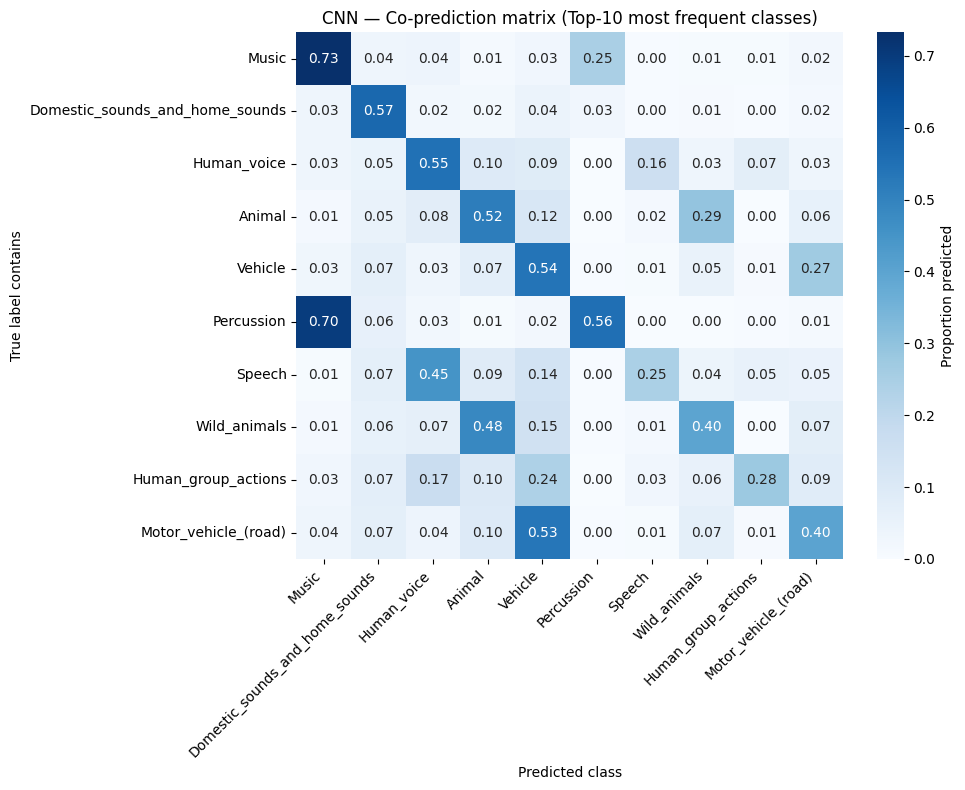

In [ ]:
# Identify the 10 most frequent test-set classes for the confusion matrix
support_counts = y_test.sum(axis=0)
top10_idx      = np.argsort(support_counts)[::-1][:10]
top10_classes  = [top_labels[i] for i in top10_idx]

# Build a 10x10 co-error matrix on binary predictions
y_pred_bin = (p_test >= best_th).astype(int)
co_err = np.zeros((10, 10), dtype=float)
for a, i in enumerate(top10_idx):
    # Rows correspond to samples whose true label contains class i
    mask = y_test[:, i] == 1
    for b, j in enumerate(top10_idx):
        # Proportion of those samples where class j was predicted
        co_err[a, b] = y_pred_bin[mask, j].sum() / max(mask.sum(), 1)

# Plot as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_err, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=top10_classes, yticklabels=top10_classes,
            cbar_kws={"label": "Proportion predicted"})
plt.title("CNN — Co-prediction matrix (Top-10 most frequent classes)")
plt.xlabel("Predicted class"); plt.ylabel("True label contains")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## **CNN Summary Table**

Consolidates the key metrics of the CNN model into a single summary table. This is the convolutional baseline against which the AST will be compared in notebook `05_ast` and under noisy conditions in `06_robutness`.

In [ ]:
cnn_summary = pd.DataFrame([{
    "Model":     "CNN (ResNet-18)",
    "Params":    f"{n_params/1e6:.1f} M",
    "Threshold": round(best_th, 2),
    "Micro-F1":  round(test_m["micro_f1"], 4),
    "Macro-F1":  round(test_m["macro_f1"], 4),
    "mAP":       round(test_m["mAP"], 4),
}])
cnn_summary

,Model,Params,Threshold,Micro-F1,Macro-F1,mAP
0,CNN (ResNet-18),11.2 M,0.3,0.5164,0.4335,0.4703


## **Discussion of Results**

### Training dynamics

Early stopping triggered at epoch 17. The best checkpoint was obtained at epoch 12 (val mAP = 0.5181). The `ReduceLROnPlateau` scheduler halved the LR at epoch 15, briefly lifting metrics but without surpassing the best checkpoint. Combined with the rising val loss after epoch 12, this indicates that the model reached its practical capacity within this training regime.

### Test performance

| Metric | Value |
|---|---|
| mAP | **0.4703** |
| Micro-F1 | **0.5164** |
| Macro-F1 | **0.4335** |

The val-to-test gap (~0.05 in mAP) is slightly above the 0.03–0.04 typical of FSD50K but remains within normal range. Absolute numbers are in line with published CNN-based baselines for FSD50K at comparable vocabulary sizes.

### Per-class insights

Top classes share distinctive spectro-temporal signatures (Music, Thunder, Applause, Cat, Explosion). Bottom classes are either broad semantic categories (Tap, Wood, Thump) or overlap acoustically with more generic labels (Bus vs Vehicle, Clapping vs Applause). This is consistent with the limitations of a local receptive field.

### Confusion analysis and hypothesis for AST

The co-prediction matrix reveals a clear pattern: the CNN systematically predicts the parent label instead of the child in hierarchical pairs. The most striking cases:

- **Percussion → Music (0.70)**
- **Motor_vehicle_(road) → Vehicle (0.53)**
- **Wild_animals → Animal (0.48)**
- **Speech → Human_voice (0.45)**

This collapse toward parent labels is the main weakness of the CNN and motivates the AST: its global attention and AudioSet pretraining should disambiguate these pairs by integrating context across the full clip. This hypothesis is tested in notebooks 05 and 06.

### Takeaway

The CNN serves as a strong convolutional baseline with interpretable failure modes. The core comparison of the project, whether AST's global attention resolves the hierarchical confusions observed here, is the focus of the next notebook.